# ECOWAS Border Trade Intelligence and Analytics

# Business Insights and Strategic Recommendations

## Impact Assessment of Simulated Regional Trade Diversion Following the AES Countries' Withdrawal from ECOWAS

### Case Study: Tsamiya–Kamba Transit Corridor

---

## Objective

This notebook transforms analytical results into business insights and strategic recommendations.

Rather than focusing only on descriptive statistics, the analysis identifies operational challenges, evaluates border performance, and proposes evidence-based recommendations that could support decision-making by customs administrations, border management agencies, and regional policymakers.

---

## Business Questions

The analysis addresses the following questions:

1. Which border posts process the highest transaction volumes?
2. Which border posts generate the highest customs revenue?
3. Which border posts experience the longest queues?
4. Which border posts require additional operational resources?
5. Which commodities contribute the highest trade value?
6. Which commodities pose the highest smuggling risk?
7. Which operational improvements would have the greatest impact?

In [91]:
# ============================================================
# Chapter 1 - Import Libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

print("Libraries imported.")

Libraries imported.


In [92]:
# ============================================================
# Chapter 2 - Load Dataset
# ============================================================

df = pd.read_csv("trade_diversion_transactions.csv")

df.head()

,Transaction_ID,Transaction_Date,Period,Origin_Country,Entry_Country,Destination_Country,Border_Post,Commodity,Vehicle_Type,Cargo_Weight_kg,Trade_Value_USD,Customs_Duty_USD,Revenue_Collected_USD,Queue_Length,Processing_Time_Minutes,Inspection_Result,Smuggling_Risk,Security_Incident,Scanner_Status,Border_Efficiency_Score
0,TRX0000001,2025-08-02,After Diversion,Togo,Cape Verde,Niger,Praia Port,Vehicles,Heavy Truck,23091.78,70960.57,9435.26,9791.44,17,25.9,Passed,Medium,No,Unavailable,98.0
1,TRX0000002,2022-08-17,Before Diversion,Nigeria,Togo,Niger,Kodjoviakope,Livestock,Heavy Truck,16533.94,63340.83,11608.49,11799.07,22,48.0,Passed,Low,No,Unavailable,82.3
2,TRX0000003,2022-02-21,Before Diversion,Benin,Benin,Niger,Hillacondji,Vehicles,Passenger Bus,943.86,13943.07,2766.44,2833.49,25,46.5,Passed,Medium,No,Unavailable,76.8
3,TRX0000004,2023-07-18,Before Diversion,Benin,Sierra Leone,Nigeria,Gbalamuya,Petroleum,Heavy Truck,18142.28,83276.36,13714.69,13775.83,6,20.5,Passed,Medium,No,Available,95.3
4,TRX0000005,2023-05-17,Before Diversion,Benin,Mali,Nigeria,Gogui,Vehicles,Heavy Truck,19017.79,62190.16,10388.67,10554.40,26,54.9,Passed,Low,No,Available,79.7


## Executive Dashboard

This section provides a high-level overview of the simulated border operations.

In [93]:
# ============================================================
# Chapter 3 - Executive KPIs
# ============================================================

print("="*60)

print("EXECUTIVE DASHBOARD")

print("="*60)

print(f"Transactions            : {len(df):,}")

print(f"Trade Value (USD)       : ${df['Trade_Value_USD'].sum():,.2f}")

print(f"Revenue (USD)           : ${df['Revenue_Collected_USD'].sum():,.2f}")

print(f"Average Queue           : {df['Queue_Length'].mean():.2f}")

print(f"Average Processing Time : {df['Processing_Time_Minutes'].mean():.2f}")

print(f"Average Efficiency      : {df['Border_Efficiency_Score'].mean():.2f}")

print(f"Security Incidents      : {(df['Security_Incident']=='Yes').sum():,}")

print(f"High-Risk Cargo         : {(df['Smuggling_Risk']=='High').sum():,}")

EXECUTIVE DASHBOARD
Transactions            : 100,000
Trade Value (USD)       : $5,329,758,582.92
Revenue (USD)           : $685,982,504.80
Average Queue           : 30.25
Average Processing Time : 54.32
Average Efficiency      : 78.53
Security Incidents      : 8,691
High-Risk Cargo         : 25,280


## Business Insight 1

Identify the busiest border posts in terms of transaction volume.

Border_Post
Malanville      6633
Hillacondji     6611
Tsamiya         6395
Kodjoviakope    6100
Cinkanse        5504
Gogui           5466
Konni           5436
Gaya            5338
Kidira          5139
Kamba           4895
Name: count, dtype: int64


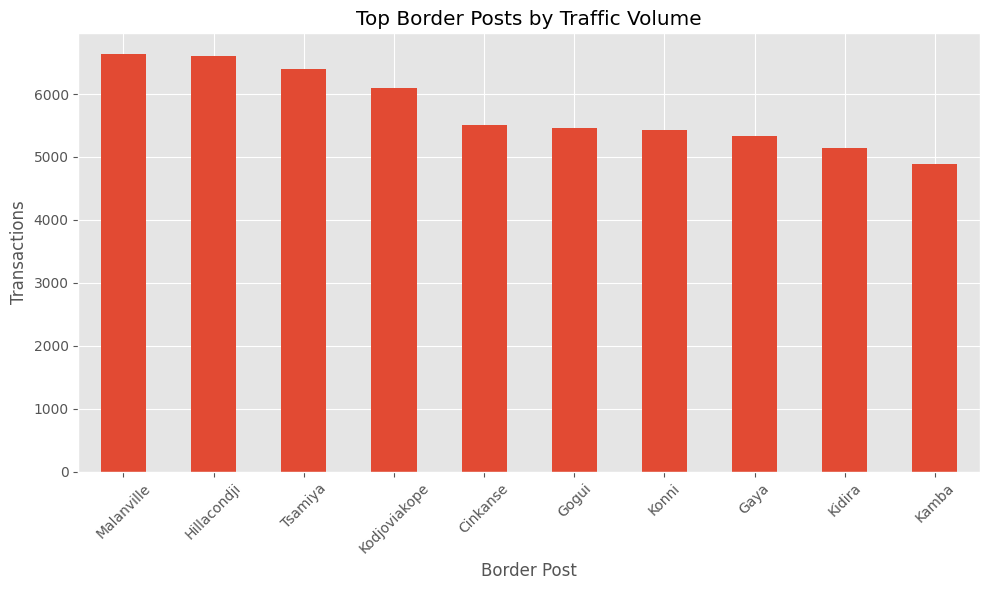

In [94]:
# ============================================================
# Chapter 4 - Traffic Volume
# ============================================================

traffic = (
    df["Border_Post"]
    .value_counts()
    .head(10)
)

print(traffic)

plt.figure(figsize=(10,6))

traffic.plot(kind="bar")

plt.title("Top Border Posts by Traffic Volume")

plt.xlabel("Border Post")

plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Business Insight

Border posts processing the highest transaction volumes experience greater operational pressure and may require additional personnel, inspection capacity, and digital infrastructure to maintain service quality.

## Business Insight 2

Identify the border posts contributing the highest customs revenue.

Border_Post
Malanville      45736299.53
Hillacondji     45471352.72
Tsamiya         43904800.29
Kodjoviakope    42272743.73
Cinkanse        37720302.83
Gaya            37357217.26
Konni           37067911.70
Gogui           37039457.22
Kidira          35005284.17
Kamba           33655170.00
Name: Revenue_Collected_USD, dtype: float64


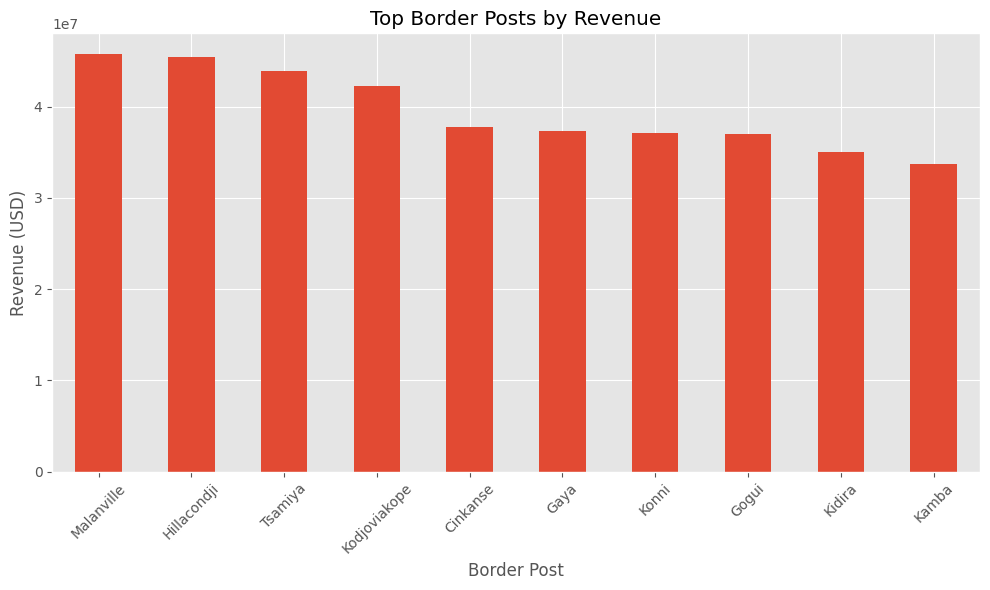

In [95]:
# ============================================================
# Chapter 5 - Revenue by Border Post
# ============================================================

revenue = (
    df.groupby("Border_Post")["Revenue_Collected_USD"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(revenue)

plt.figure(figsize=(10,6))

revenue.plot(kind="bar")

plt.title("Top Border Posts by Revenue")

plt.xlabel("Border Post")

plt.ylabel("Revenue (USD)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Business Insight

Border posts generating the highest revenue represent strategic economic assets. Continued investment in these locations can improve revenue collection while supporting regional trade facilitation.

## Business Insight 3

This analysis identifies the border posts with the highest average queue length.

Long queues indicate operational pressure and may require additional resources or process improvements.

Border_Post
Tsamiya         71.713995
Kamba           69.267824
Seme            45.165341
Malanville      45.140510
Gbalamuya       22.742503
Bo Waterside    22.727119
Elubo           22.696970
Pogo            22.656292
Hillacondji     22.611556
Gogui           22.610318
Name: Queue_Length, dtype: float64


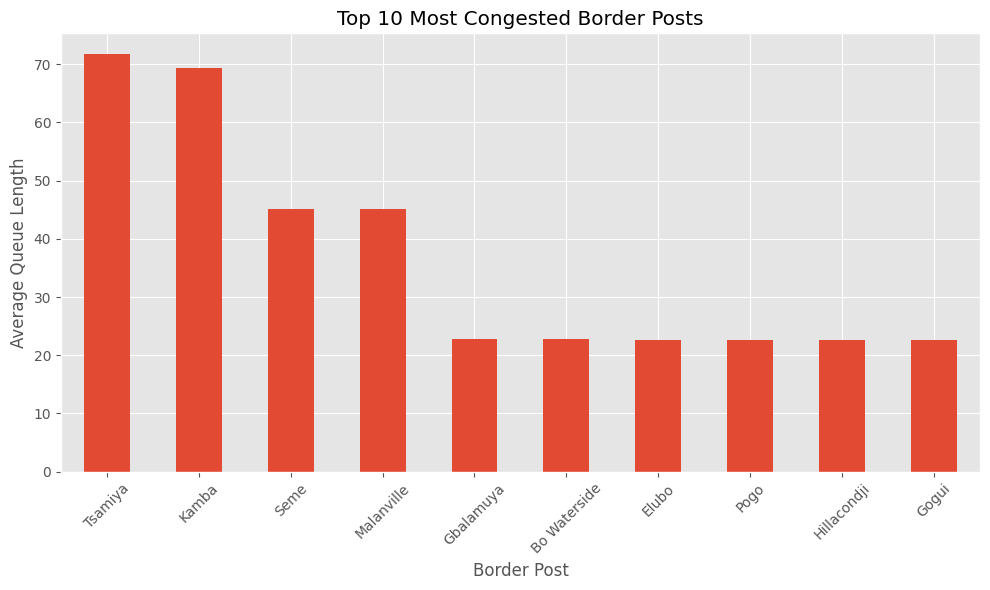

In [96]:
# ============================================================
# Chapter 6 - Border Congestion Ranking
# ============================================================

congestion = (
    df.groupby("Border_Post")["Queue_Length"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(congestion)

plt.figure(figsize=(10,6))

congestion.plot(kind="bar")

plt.title("Top 10 Most Congested Border Posts")

plt.xlabel("Border Post")

plt.ylabel("Average Queue Length")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Business Insight

Border posts with the longest queues should be prioritized for infrastructure expansion, additional officers, and improved traffic management systems.

## Business Insight 4

Processing time is a key indicator of operational efficiency.

This analysis identifies border posts where customs processing takes the longest.

Border_Post
Tsamiya         108.034965
Kamba           105.138631
Malanville       73.590351
Seme             73.537813
Bo Waterside     44.710113
Gbalamuya        44.641782
Pogo             44.576874
Gogui            44.474515
Hillacondji      44.435380
Kodjoviakope     44.413033
Name: Processing_Time_Minutes, dtype: float64


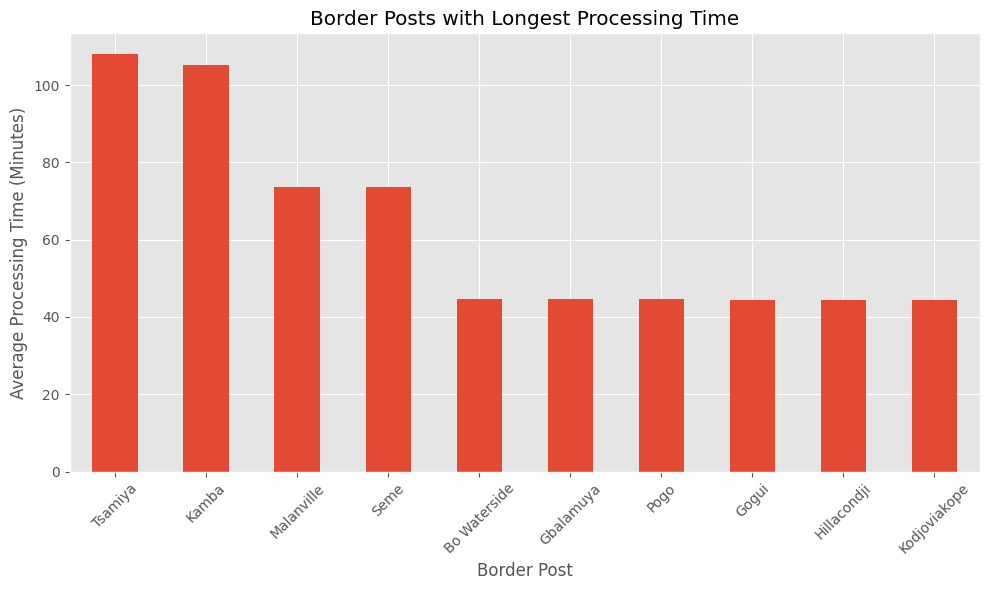

In [97]:
# ============================================================
# Chapter 7 - Processing Time Ranking
# ============================================================

processing = (
    df.groupby("Border_Post")["Processing_Time_Minutes"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(processing)

plt.figure(figsize=(10,6))

processing.plot(kind="bar")

plt.title("Border Posts with Longest Processing Time")

plt.xlabel("Border Post")

plt.ylabel("Average Processing Time (Minutes)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Business Insight

Long processing times may indicate capacity constraints, manual procedures, or increased inspection workloads. Digital automation and workflow optimization can improve processing efficiency.

## Business Insight 5

This analysis identifies the commodities contributing the highest total trade value.

These commodities represent major drivers of regional trade activity.

Commodity
Rice                      8.650819e+08
Petroleum                 7.418711e+08
Construction Materials    5.823168e+08
Electronics               5.371690e+08
Vehicles                  4.843910e+08
Textiles                  4.841460e+08
Livestock                 4.813193e+08
Pharmaceuticals           4.743106e+08
Agricultural Produce      4.130169e+08
Fertilizer                2.661360e+08
Name: Trade_Value_USD, dtype: float64


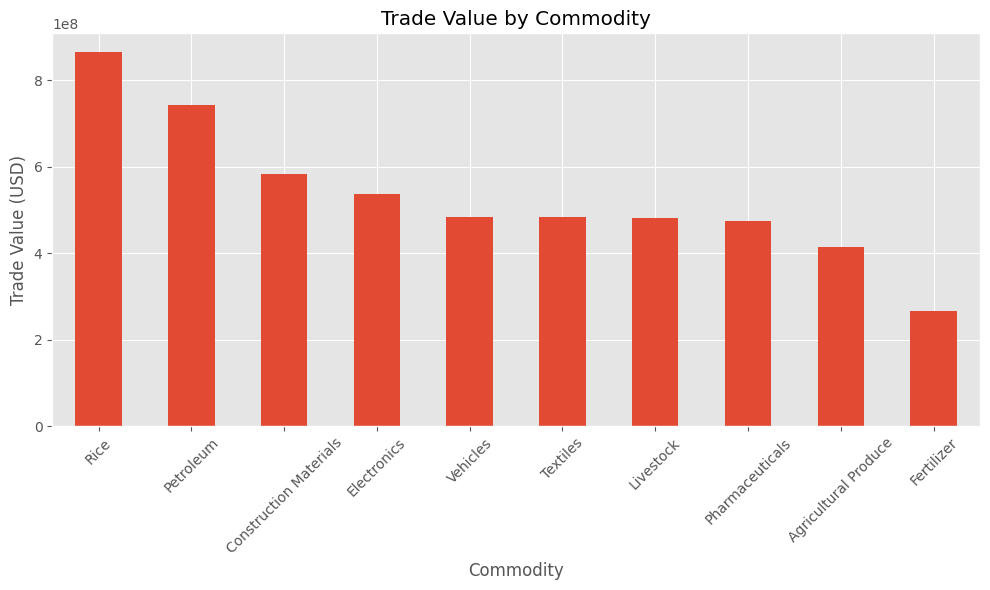

In [98]:
# ============================================================
# Chapter 8 - Trade Value by Commodity
# ============================================================

trade_value = (
    df.groupby("Commodity")["Trade_Value_USD"]
      .sum()
      .sort_values(ascending=False)
)

print(trade_value)

plt.figure(figsize=(10,6))

trade_value.plot(kind="bar")

plt.title("Trade Value by Commodity")

plt.xlabel("Commodity")

plt.ylabel("Trade Value (USD)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Business Insight

Commodities generating the highest trade value have significant economic importance. Ensuring efficient clearance for these goods can support regional economic growth.

## Business Insight 6

This section identifies the commodities contributing the highest customs revenue.

Commodity
Rice                      1.109856e+08
Petroleum                 9.575366e+07
Construction Materials    7.453293e+07
Electronics               6.930176e+07
Textiles                  6.235231e+07
Vehicles                  6.225603e+07
Livestock                 6.220152e+07
Pharmaceuticals           6.107939e+07
Agricultural Produce      5.333761e+07
Fertilizer                3.418171e+07
Name: Revenue_Collected_USD, dtype: float64


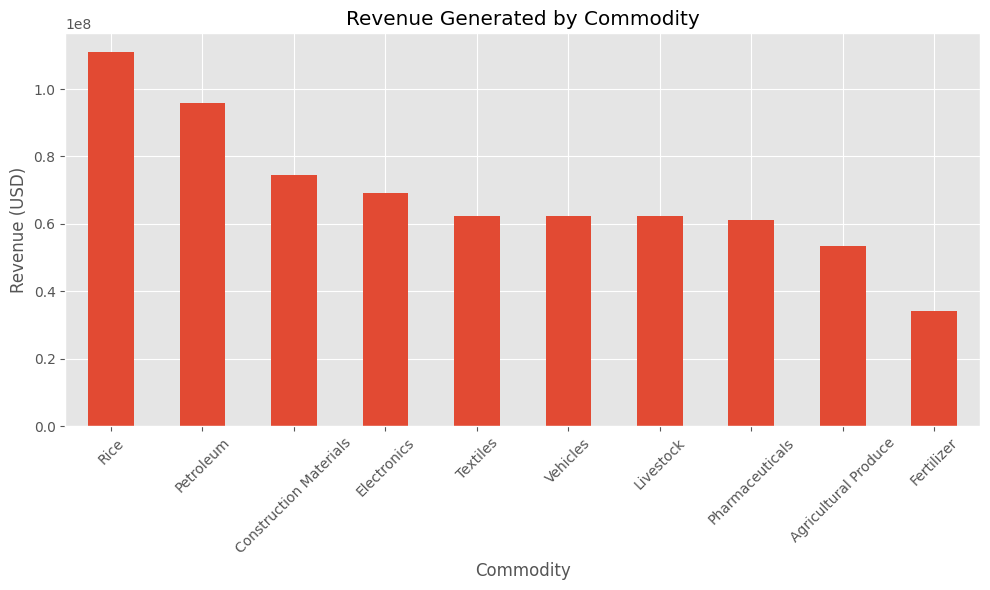

In [99]:
# ============================================================
# Chapter 9 - Revenue by Commodity
# ============================================================

commodity_revenue = (
    df.groupby("Commodity")["Revenue_Collected_USD"]
      .sum()
      .sort_values(ascending=False)
)

print(commodity_revenue)

plt.figure(figsize=(10,6))

commodity_revenue.plot(kind="bar")

plt.title("Revenue Generated by Commodity")

plt.xlabel("Commodity")

plt.ylabel("Revenue (USD)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Business Insight

High-revenue commodities should receive appropriate operational attention to ensure efficient processing while maintaining effective customs compliance.

## Business Insight 7

This analysis identifies commodity groups with the largest number of high-risk shipments.

Commodity
Petroleum                 5615
Electronics               4061
Pharmaceuticals           3516
Rice                      2858
Construction Materials    1991
Textiles                  1670
Livestock                 1643
Vehicles                  1620
Agricultural Produce      1417
Fertilizer                 889
dtype: int64


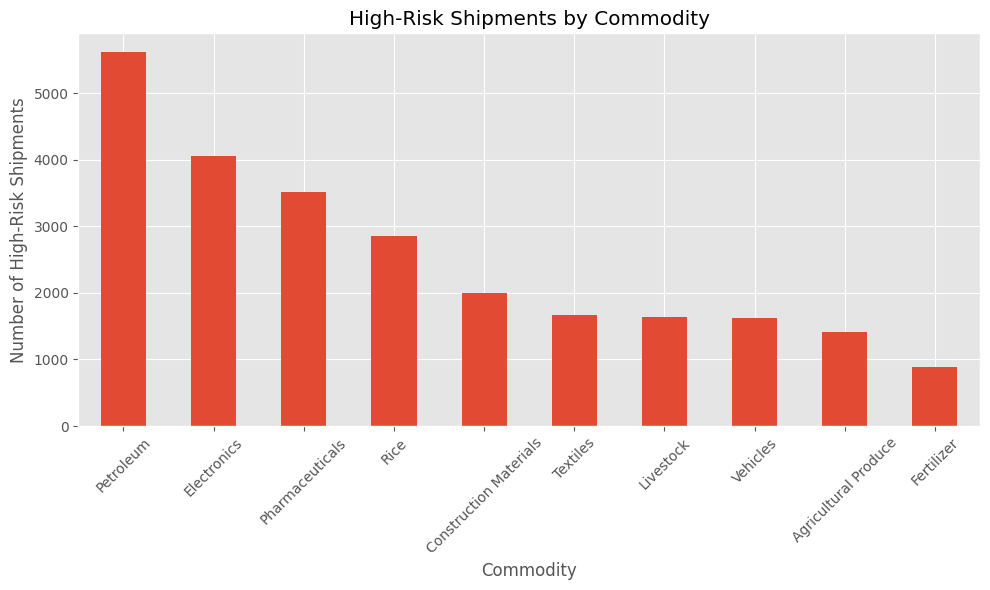

In [100]:
# ============================================================
# Chapter 10 - High-Risk Commodities
# ============================================================

high_risk = (
    df[df["Smuggling_Risk"] == "High"]
    .groupby("Commodity")
    .size()
    .sort_values(ascending=False)
)

print(high_risk)

plt.figure(figsize=(10,6))

high_risk.plot(kind="bar")

plt.title("High-Risk Shipments by Commodity")

plt.xlabel("Commodity")

plt.ylabel("Number of High-Risk Shipments")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Business Insight

Commodities with higher numbers of high-risk shipments may benefit from intelligence-led inspections, targeted scanning, and enhanced risk profiling.

## Business Insight 8

This scorecard summarizes key operational indicators for each border post, allowing management to compare performance across locations.

In [101]:
# ============================================================
# Chapter 11 - Border Performance Scorecard
# ============================================================

scorecard = (
    df.groupby("Border_Post")
    .agg({
        "Transaction_ID":"count",
        "Revenue_Collected_USD":"sum",
        "Queue_Length":"mean",
        "Processing_Time_Minutes":"mean",
        "Border_Efficiency_Score":"mean"
    })
    .rename(columns={
        "Transaction_ID":"Transactions",
        "Revenue_Collected_USD":"Revenue_USD",
        "Queue_Length":"Avg_Queue",
        "Processing_Time_Minutes":"Avg_Processing_Time",
        "Border_Efficiency_Score":"Efficiency_Score"
    })
    .sort_values("Transactions", ascending=False)
)

scorecard.head(10)

,Transactions,Revenue_USD,Avg_Queue,Avg_Processing_Time,Efficiency_Score
Border_Post,,,,,
Malanville,6633,45736299.53,45.140510,73.590351,69.416011
Hillacondji,6611,45471352.72,22.611556,44.435380,83.208546
Tsamiya,6395,43904800.29,71.713995,108.034965,53.286396
Kodjoviakope,6100,42272743.73,22.604426,44.413033,83.182443
Cinkanse,5504,37720302.83,22.549964,44.344967,83.208703
Gogui,5466,37039457.22,22.610318,44.474515,83.138273
Konni,5436,37067911.70,22.474982,44.163723,83.310063
Gaya,5338,37357217.26,22.495879,44.142806,83.297377
Kidira,5139,35005284.17,22.347149,44.291594,83.227145


### Business Insight

The scorecard provides a consolidated view of border performance. It helps identify border posts that combine high traffic with long queues and lower efficiency, making them priorities for operational improvement.

## Business Insight 9

Border posts with high traffic, long queues, and lower efficiency should receive priority attention.

In [102]:
# ============================================================
# Chapter 12 - Priority Border Posts
# ============================================================

priority = scorecard.sort_values(
    by=["Avg_Queue","Efficiency_Score"],
    ascending=[False,True]
)

priority.head(10)

,Transactions,Revenue_USD,Avg_Queue,Avg_Processing_Time,Efficiency_Score
Border_Post,,,,,
Tsamiya,6395,43904800.29,71.713995,108.034965,53.286396
Kamba,4895,33655170.00,69.267824,105.138631,54.654362
Seme,3520,23695650.77,45.165341,73.537813,69.440739
Malanville,6633,45736299.53,45.140510,73.590351,69.416011
Gbalamuya,3468,23821839.56,22.742503,44.641782,83.163783
Bo Waterside,3540,24217075.11,22.727119,44.710113,83.085706
Elubo,2706,18308650.53,22.696970,44.271877,83.246489
Pogo,2988,20295565.32,22.656292,44.576874,83.173728
Hillacondji,6611,45471352.72,22.611556,44.435380,83.208546


### Business Insight

These border posts should be considered first for additional officers, inspection lanes, scanning equipment, and digital process improvements.

## Resource Allocation Priorities

The following recommendations are based on the analytical findings.

In [103]:
# ============================================================
# Chapter 13 - Recommended Actions
# ============================================================

recommendations = pd.DataFrame({

    "Priority Border Post": priority.head(10).index,

    "Recommended Action":[

        "Increase officers",
        "Install additional scanners",
        "Expand inspection lanes",
        "Improve digital processing",
        "Increase risk-based inspections",
        "Deploy mobile inspection teams",
        "Upgrade ICT infrastructure",
        "Improve cargo parking",
        "Increase supervisory staff",
        "Continuous performance monitoring"

    ]

})

recommendations

,Priority Border Post,Recommended Action
0,Tsamiya,Increase officers
1,Kamba,Install additional scanners
2,Seme,Expand inspection lanes
3,Malanville,Improve digital processing
4,Gbalamuya,Increase risk-based inspections
5,Bo Waterside,Deploy mobile inspection teams
6,Elubo,Upgrade ICT infrastructure
7,Pogo,Improve cargo parking
8,Hillacondji,Increase supervisory staff
9,Gogui,Continuous performance monitoring


In [104]:
# ============================================================
# Export Business Reports
# ============================================================

scorecard.to_csv(
    "border_performance_scorecard.csv",
    index=True
)

recommendations.to_csv(
    "resource_allocation_recommendations.csv",
    index=False
)

print("Business reports exported successfully.")

Business reports exported successfully.


# Executive Management Report

## Key Findings

- Border traffic increased substantially at selected Nigerian border posts after the simulated trade diversion.
- Increased traffic resulted in longer queues and longer processing times.
- Higher trade activity generated additional customs revenue.
- Border efficiency declined where congestion increased.
- Certain commodities generated higher trade value and customs revenue.
- High-risk cargo remained concentrated within selected commodity groups.

## Operational Priorities

- Increase staffing at high-volume border posts.
- Expand inspection infrastructure.
- Deploy additional cargo scanners.
- Improve digital customs processing.
- Strengthen intelligence-led inspections.
- Continue monitoring operational performance through data analytics.

## Expected Benefits

Implementation of these recommendations may reduce congestion, improve processing efficiency, enhance revenue collection, strengthen border security, and support regional trade facilitation.

# Conclusion

This notebook translated analytical results into practical business insights for border management.

The analysis demonstrates how data can support operational decision-making by identifying performance gaps, prioritizing resource allocation, and informing strategic planning.

Although the dataset is synthetic, the analytical framework reflects approaches that can be applied to real operational data within customs administrations, border management agencies, and regional organizations.